# Eigenvalues in the wild: a random-matrix laboratory

The covariance matrix is clearly the load-bearing object of quantitative finance. Full stop.
From portfolio construction, to risk budgeting, to hedging, everything eventually comes
knocking at its door. Now, aside from then being clearly busy, every covariance matrix 
we will ever hold was *estimated*: $N(N+1)/2$ parameters from $N \times T$ numbers. And this
is a problem. Indeed, we can see that the natural small parameter in this case, i.e., 

$$q = \frac{N}{T},$$

just refuses to be small. How? Let us take 500 names returns $\times$ two years of daily data. This is
$q \approx 1$. Things get ugly fast and the asymptotic limit of small $q$ is not even on the horizon.
We will thus use data as i.i.d. as data can be, and employ Random Matrix Theory (RMT) to 
navigate this sea together. A warning, I might be ok in cosmology but this here is my first boat ride 
in quantative finance, so hold on tight...

Our master plan:

**The starting line (Part 0).** We simply observe that using the in-sample covariance
matrix is a real problem in risk estimation. Then we take it from there.

**The laws (Parts 1–3).** We go and take a look at how the eigenvalues of pure noise look like. 
To wit, we construct Wigner's semicircle law, the Marchenko–Pastur distribution, and  confront universality, 
i.e., the discovery that these shapes do not care much about the distribution of the entries. 
One cannot really recognise *something* if one does not know what *nothing* looks like. 

**Laws are meant to be broken (Parts 4–5).** Reading the fine prints is always a bore but 
genuinely important. In this case, we know that universality has fine prints about moments (just 
as the CLT has). Sadly for us, finance is precisely the industry that violates these fine prints. 
We thus use Student-t entries (the edge breaks before the bulk), elliptical returns (fat tails 
"the simple market's way": one volatility shared by everyone), and a Lévy coda where even 
the semicircle dies. All to look into this.

**Using the laws (Parts 6–7).** When can we actually see something? Here we look into that 
and we follow-up with a nice payoff: an estimator shoot-out (sample, clipping, Ledoit–Wolf, RIE) scored 
against the *known* truth. Minding at the same time that also this *truth* in reality might
not really apply.

**What to do next? (Part 8).** A simple checklist of things to do when working on real data in 
the *narrative_rmt_market.ipynb* to be built.

Everything runs on `rmt_lab.py` (pure numpy, seeded). Central companion texts: Potters &
Bouchaud, *A First Course in Random Matrix Theory*  and Bun, Bouchaud & Potters, *Cleaning                                            large correlation matrices* (2017). Other references are reported in the README files and
at the end of this notebook. All are cited when needed in the text.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rmt_lab import (
    goe, wigner, sample_entries, sample_stable, returns_gaussian, returns_student,
    sample_cov, sample_corr,
    semicircle_pdf, mp_pdf, mp_edges,
    spiked_cov, bbp_threshold, spike_lambda, spike_overlap2,
    eigh_desc, ipr, recompose,
    xi_clip, lw_shrinkage, xi_rie, xi_oracle, clean_cov,
    min_var_weights, portfolio_variance, frobenius, risk_report,
    day_scale, max_to_sum_ratio, kappa, normal_scores,
)

SEED = 20260901
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3 = "C0", "C1", "C2", "C3"


def esd(ax, lam, bins=50, color=C0, label="eigenvalues", clip=None):
    # Histogram of an empirical spectral distribution, density-normalised.
    if clip is not None:
        lam = lam[(lam >= clip[0]) & (lam <= clip[1])]
    ax.hist(lam, bins=bins, density=True, color=color, alpha=0.55, label=label)

## Part 0 — The in-sample covariance matrix is a compulsive liar

We accuse the in-sample covariance matrix to lie blatantly and repeatedly. How come? 
Let us see.

Imagine to take the safest world imaginable: $N$ assets, all with unit variance, 
and with **zero true correlation**. Literally a dream in which the population covariance is 
the identity, nothing is fat-tailed, and everything is a bit boring.

In this case, we see that the optimal minimum-variance portfolio is just equal weight, 
with volatility $1/\sqrt{N}$. Indeed, we have a set of fully invested weights $w \in \mathbb{R}^N$, 
namely such that $\mathbf{1}^\top w = 1$, and a population covariance $C = I_N$. Portfolio variance 
is just $\sigma_p^2 = w^\top C w = w^\top w = \sum_{i=1}^N w_i^2$. So the min-variance problem 
becomes simply

$$\min_{w} \; \|w\|_2^2 \quad \text{s.t.} \quad \mathbf{1}^\top w = 1 \, .$$

We can solve it via a simple use of Lagrange multipliers, i.e., by setting

$$\mathcal{L}(w, \lambda) = w^\top w - \lambda \left( \mathbf{1}^\top w - 1 \right) \, ,$$

and then taking the first-order condition

$$\nabla_w \mathcal{L} = 2w - \lambda \mathbf{1} = 0 \quad \Longrightarrow \quad w = \tfrac{\lambda}{2} \mathbf{1} \, .$$

Clearly, every weight is the same. Now, by imposing the budget constraint $\tfrac{\lambda}{2} N = 1$ we get $\lambda = 2/N$, 
and hence $w_i^\star = \frac{1}{N}$ with $ \mathrm{Vol} = \sigma_p =  1/\sqrt{N}$.

Now, what if we did the most simple thing we could try to do? Namely, let us estimate the covariance from $T$
observations (here, $T >N$) and build the min-variance portfolio from the estimate. By following the same argument as above we would 
now obtain weights of the kind $\hat{w} = \frac{E^{-1}\mathbf{1}}{\mathbf{1}^\top E^{-1}\mathbf{1}}$. The points is that now 
three volatilities exist for that portfolio: 

| | definition | meaning |
| :-- | :-- | :-- |
| **believed** | $\sigma_{\text{in}}^2 = \hat{w}^\top E \hat{w}$ | what the optimizer reports |
| **realized** | $\sigma_{\text{out}}^2 = \hat{w}^\top C \hat{w}$ | what you actually get  |
| **optimal** | $\sigma_{\text{true}}^2 = w^{\star\top} C w^\star = 1/N$ | the unreachable optimum |

The point is that  one can show (see Chapter 20 of  Potters & Bouchaud, *A First Course in Random Matrix Theory* for a derivation 
within an even more general setting) 

$$\frac{\sigma_{\text{in}}}{\sigma_{\text{true}}} = \sqrt{1-q}, \qquad\qquad \frac{\sigma_{\text{out}}}{\sigma_{\text{true}}} = \frac{1}{\sqrt{1-q}} \, .$$

Namely, the estimator based on the sample covariance is wrong twice, in opposite directions, by the same factor. It *under*states the risk of a portfolio that is *worse* than it thinks. Since we are lucky, we also note that the two errors compound rather than cancel. A quick numeric check with a Monte Carlo simulation will convince us.

In [2]:
N, REPS = 250, 25
rows = []
for q in (0.10, 0.50, 0.90):
    T = int(round(N / q))
    believed, realized = [], []
    for _ in range(REPS):
        rep = risk_report(sample_cov(returns_gaussian(N, T, rng)), np.eye(N))
        believed.append(rep["in_sample"])
        realized.append(rep["realized"])
    opt = 1.0 / np.sqrt(N)
    rows.append({
        "believed vol": np.mean(believed),
        "realized vol": np.mean(realized),
        "optimal vol": opt,
        "believed/opt": np.mean(believed) / opt,
        "theory √(1−q)": np.sqrt(1 - q),
        "realized/opt": np.mean(realized) / opt,
        "theory 1/√(1−q)": 1 / np.sqrt(1 - q),
    })
pd.DataFrame(rows, index=pd.Index((0.10, 0.50, 0.90), name="q")).round(3)

,believed vol,realized vol,optimal vol,believed/opt,theory √(1−q),realized/opt,theory 1/√(1−q)
q,,,,,,,
0.1,0.060,0.067,0.063,0.946,0.949,1.055,1.054
0.5,0.044,0.090,0.063,0.702,0.707,1.415,1.414
0.9,0.020,0.196,0.063,0.313,0.316,3.103,3.162


Bingo! The theory columns match the Monte Carlo to the third digit, really not bad. 
So, if we were to use the in-sample covariance:

**1. We would be deadly wrong in our estimates.** At $q=1/2$ the portfolio understimates the 
realised volatily by 50%. At $q=0.9$ the self-deception is a full order of magnitude. 

**2. The failure is purely a consequence of dimensions.** We are using gaussian data, i.i.d. 
in every direction, and as population covariance the friendliest object in linear algebra.
Still our simple estimator fails. The mechanism?  It has to do with *eigenvalues*. Indeed,
with $q$ not small, the *eigenvalues* of $E$ spread far from 1 even though every true 
eigenvalue equals 1, and $E^{-1}$ greedily loads on the (spuriously) small ones. 
To wit, this simple estimator mistakes its own noise for hedging opportunities.

## Part 1 — Wigner's semicircle: what pure noise looks like

The simplest random matrix we can think of is a symmetric $N \times N$ matrix
of i.i.d. noise, normalised for good measure by $\sqrt{N}$ (note that to work in
the Gaussian Orthogonal Ensamble (GOE) we should consider diagonal entries with double the 
variance of the off-diagonal ones, but at this level it is not needed). The matrix elements are therefore: 

$$H_{ij} = H_{ji} \sim \frac{\text{i.i.d. mean 0, variance }1}{\sqrt{N}} \, ,$$

Wigner (1955) asked what the eigenvalues of such a matrix look like. Now, his motivation was
the study of heavy nuclei, ours is that $H$ is the mother of every "pure noise" model. 
Nonetheless, of course the answer is the same. And, the answer is the semicircle law: 
the empirical spectral distribution (ESD) converges in the large $N$ limit to

$$\rho(x) = \frac{1}{2\pi}\sqrt{4 - x^{2}}, \qquad x \in [-2, 2]\,.$$

Note that this is a statement about *eigenvalues of noise being deterministic*. Indeed, although 
the entries are random, the histogram of eigenvalues converges to a fixed shape with fixed edges. 

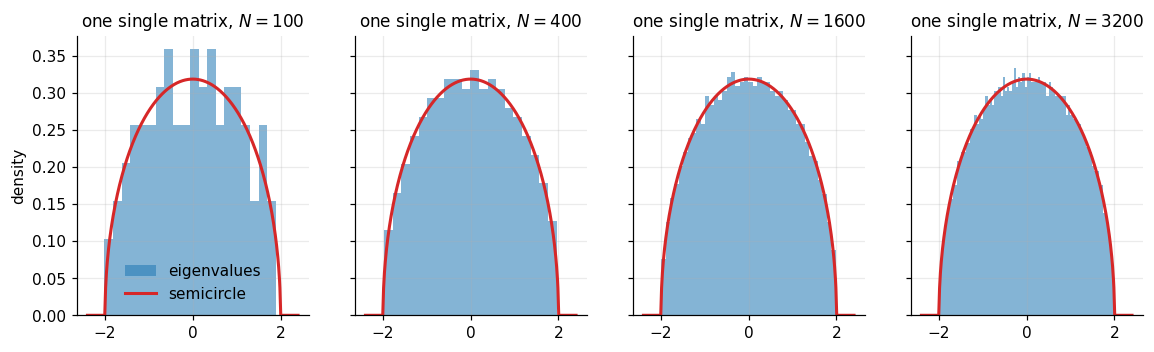

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3), sharey=True)
x = np.linspace(-2.4, 2.4, 500)
for ax, n in zip(axes, (100, 400, 1600, 3200)):
    lam = np.linalg.eigvalsh(goe(n, rng))
    esd(ax, lam, bins=max(20, n // 40))
    ax.plot(x, semicircle_pdf(x), color=C3, lw=2, label="semicircle")
    ax.set_title(f"one single matrix, $N={n}$")
axes[0].set_ylabel("density")
axes[0].legend(loc ="best")

Each panel is **one** matrix, we are not taking any ensemble averaging anywhere! The convergence
is really quite fast. This is *self-averaging*: a large random matrix behaves like its
own ensemble, because the ESD's fluctuations die off like $1/N$ (much faster than the
$1/\sqrt{N}$ of ordinary sample means, due to the fact that eigenvalues "repel" each other, which suppresses
fluctuations). Self-averaging is why RMT really is usable in practice! When working we 
will only ever hold *one* sample covariance matrix, and the theory will apply to it directly. 
Sometimes we do get lucky after all.

Now, interestingly, the picture emerging from the above plot is that the bulk of the distribution is quite stable. 
But what about the edge? In particular, what about the largest eigenvalue?

scaled edge: mean = -1.481   sd = 1.247   skewness = +0.279


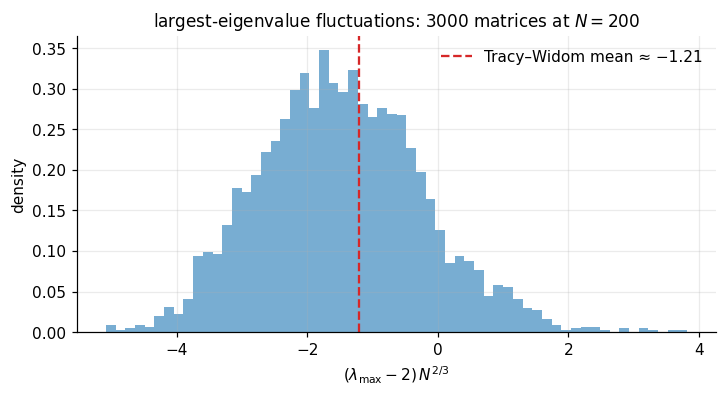

In [4]:
N_EDGE, DRAWS = 200, 3000
lmax = np.empty(DRAWS)
for i in range(DRAWS):
    lmax[i] = np.linalg.eigvalsh(goe(N_EDGE, rng))[-1]
scaled = (lmax - 2.0) * N_EDGE ** (2 / 3)

fig, ax = plt.subplots(figsize=(7.5, 3.5))
ax.hist(scaled, bins=60, density=True, color=C0, alpha=0.6)
ax.axvline(-1.21, color=C3, ls="--", lw=1.5, label="Tracy–Widom mean ≈ −1.21")
ax.set_xlabel(r"$(\lambda_{\max} - 2)\,N^{2/3}$")
ax.set_ylabel("density")
ax.set_title(f"largest-eigenvalue fluctuations: {DRAWS} matrices at $N={N_EDGE}$")
ax.legend()
skew = ((scaled - scaled.mean()) ** 3).mean() / scaled.std() ** 3
print(f"scaled edge: mean = {scaled.mean():+.3f}   sd = {scaled.std():.3f}   skewness = {skew:+.3f}")

The largest eigenvalue fluctuates at a typical scale $N^{-2/3}$ — namely, in between the bulk's $1/N$
and a sample mean's $1/\sqrt{N}$. Remarkably, it has its own limiting law for
typical fluctuations (Tracy–Widom; asymmetric, as the histogram shows). Overall, the plot 
above tells us that:

**1. Edges are softer than bulks.** Indeed, with little "repelling force" (which is what stabilises the bulk) they undergo greater fluctuations.

**2. $N^{-2/3}$ is actually the noise floor of detection for typical fluctuations.** 
Indeed, the question "Is this eigenvalue above the edge for a typical fluctuation?" can only ever be answered to within the Tracy–Widom set-up. Note also that at $N=200$ the histogram's centre still sits a good $0.3$ to the *left* of the asymptotic $-1.21$. To wit, preasymptotics will be with us quite often as limit laws can converge slowly.

## Part 2 — Marchenko–Pastur: the null model of every correlation matrix

Now we can move on to the kind of matrices that come up in finance, i.e., *Wishart matrices*. Take returns $X \in \mathbb{R}^{N\times T}$
with i.i.d. entries (mean 0, variance 1 — so the *true* covariance is the identity), and form the sample covariance

$$E = \frac{1}{T} X X^{\top}.$$

With $T \to \infty$ at fixed $N$, $E \to I$: all eigenvalues 1. This is not the case, however, when we consider $q = N/T$ finite.
Then the ESD of $E$ converges in the large $N$ (or $T$) limit to the Marchenko & Pastur (1967) distribution. Namely,

$$\rho(\lambda) = \frac{\sqrt{(\lambda_{+}-\lambda)(\lambda-\lambda_{-})}}{2\pi q \lambda},
\qquad \lambda_{\pm} = (1 \pm \sqrt{q})^{2}.$$

The true spectrum of the population covariance would be a delta at 1. Instead, the sample spectrum is a *band* around 1 whose width
is set by $q$ alone. Of course, for $N > T$ (i.e., $q > 1$) we find that $N - T$ eigenvalues live exactly at $0$, and $E$ is singular. Then a delta of dirac is technically present carrying some of the total weight.

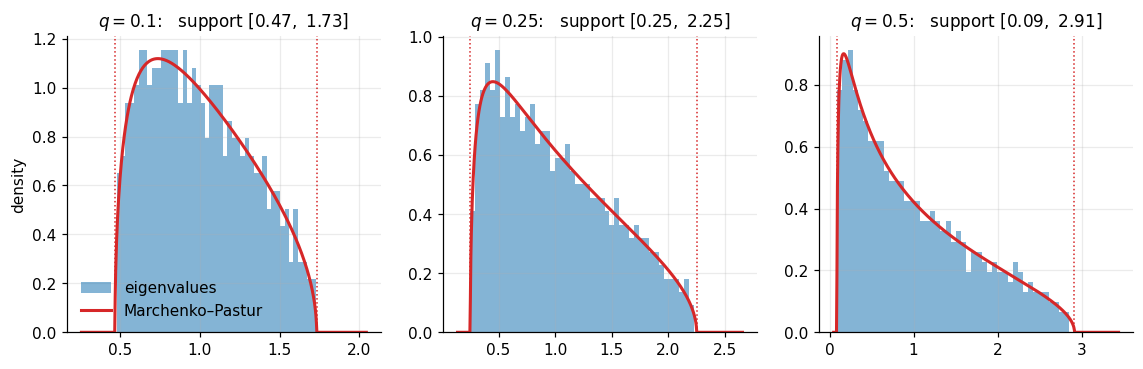

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))
N = 500
for ax, q in zip(axes, (0.10, 0.25, 0.50)):
    T = int(N / q)
    lam = np.linalg.eigvalsh(sample_cov(returns_gaussian(N, T, rng)))
    esd(ax, lam, bins=45)
    lm, lp = mp_edges(q)
    x = np.linspace(max(1e-3, lm * 0.55), lp * 1.18, 600)
    ax.plot(x, mp_pdf(x, q), color=C3, lw=2, label="Marchenko–Pastur")
    for edge in (lm, lp):
        ax.axvline(edge, color=C3, ls=":", lw=1)
    ax.set_title(rf"$q={q}$:   support $[{lm:.2f},\ {lp:.2f}]$")
axes[0].set_ylabel("density")
axes[0].legend()

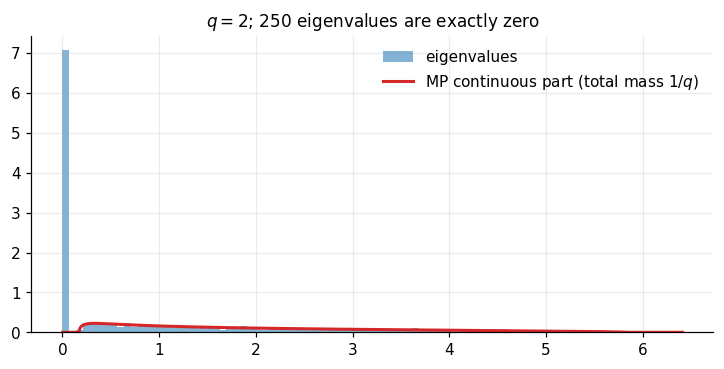

In [6]:
N, T = 500, 250                    # q = 2: more assets than observations
lam = np.linalg.eigvalsh(sample_cov(returns_gaussian(N, T, rng)))
q = N / T
n_zero = int(np.sum(lam < 1e-10))

fig, ax = plt.subplots(figsize=(8, 3.5))
esd(ax, lam, bins=80)
x = np.linspace(1e-3, mp_edges(q)[1] * 1.1, 600)
ax.plot(x, mp_pdf(x, q), color=C3, lw=2, label="MP continuous part (total mass $1/q$)")
ax.set_title(f"$q = {q:.0f}$; {n_zero} eigenvalues are exactly zero")
ax.legend()

From the two plots above (and the MP law) we conclude easily that:

**1. A spread in eigenvalues follows without correlation.** At $q=0.25$ the sample eigenvalues span
$[0.25,\ 2.25]$ while every true eigenvalue is 1. The MP band is then the *null hypothesis* of
correlation-matrix mining.

**2. The edges are deterministic and $q$-controlled.** If we were to halve the data, then the band
would widen by a predictable amount. Note that a consquence is that: only eigenvalues **above** 
$\lambda_{+} = (1+\sqrt{q})^2$ can be candidate signal.

**3. The $q > 1$ is workable (and also not rare)** 500 names on one year of daily data gives
$q \sim 2$. As such, the sample covariance is *singular*. Therefore, in this standard cases the 
naive min-variance optimiser divides by zero, or worse, by almost-zero. As such, cleaning a covariance
matrix (as we will see) is fundamental.

Importantly, the Tracy-Widow distribution for the typical fluctuations of the largest eigenvalue 
apply to MP as much as to the semi-circle. Now, however, before moving on let us also consider 
the question of large deviations from the edge.

### Beyond TW: large deviations of the edge

TW cannot reply to the question: *what is the probability that pure noise throws an
eigenvalue a finite (large) distance beyond the edge?* To answer this question we 
got to move within large-deviation theory (LDT). In particular, the Coulomb-gas calculation 
for exactly our Wishart/MP case for the Gaussian ensembles (see Dean & Majumdar, PRL **97**, 160201 (2006), 
and Majumdar & Vergassola, PRL **102**, 060601 (2009)) gives, for $x > \lambda_+$:

$$\Pr(\lambda_1 > x) \;\asymp\; e^{-N\,\Psi_+(x)}\,,
\qquad
\Psi_+(x) = \frac{1}{2}\int_{\lambda_+}^{x}
\frac{\sqrt{(y-\lambda_-)(y-\lambda_+)}}{q\,y}\,dy \,,$$

where $\Psi_+(x)$ represents effectively the energy of dragging **one** charge out of the Coulomb-gas sea against 
its pull. Interestingly, note that the the integrand vanishes like $\delta = (t-\lambda_+)^{1/2}$ at the edge, so
$\Psi_+ \sim \delta^{3/2}$ and the LD regime matches onto TW's window smoothly.

Finally, we remark that the *left* tail is a different universe altogether. Indeed, forcing $\lambda_{\rm max}$ **below** $\lambda_+$
means compressing the *entire sea* of eigenvalues, and costs $e^{-N^2 \Phi_-}$. This
$e^{-N}$-versus-$e^{-N^2}$ asymmetry — which essentialy says that eigenvalues escape one at a time, 
but the bulk moves together — meets at the edge in a **third-order phase transition** (see Majumdar &
Schehr's 2014 review). 

Ultimately, this asymmetry is the deep reason why the MP bulk is so rigid in every histogram above 
while single outliers are merely *rare*. In other words, the bulk eats signal and the edges is where
to look for genuine information.

N=200, q=0.25: an eigenvalue at 2.3 under pure noise costs ~ exp(-1.9) ≈ 1e-1
N=200, q=0.25: an eigenvalue at 2.6 under pure noise costs ~ exp(-33.4) ≈ 1e-14
N=200, q=0.25: an eigenvalue at 3.0 under pure noise costs ~ exp(-100.6) ≈ 1e-44


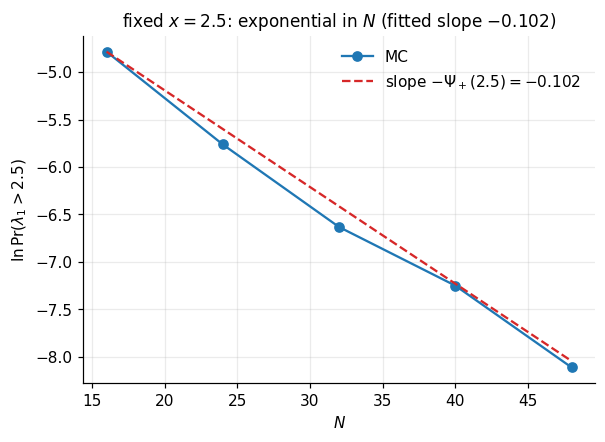

In [7]:
def psi_plus(x, q, npts=3000):
    # right large-deviation rate for the MP top eigenvalue 
    lm_, lp_ = mp_edges(q)
    x = np.atleast_1d(np.asarray(x, float))
    out = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi > lp_:
            t = np.linspace(lp_, xi, npts)
            out[i] = 0.5 * np.trapezoid(np.sqrt((t - lm_) * (t - lp_)) / (q * t), t)
    return out

def wishart_lmax(n, t, n_draws, rg, chunk=3000):
    out = np.empty(n_draws)
    for s in range(0, n_draws, chunk):
        b = min(chunk, n_draws - s)
        Xb = rg.standard_normal((b, n, t))
        out[s:s + b] = np.linalg.eigvalsh(Xb @ Xb.transpose(0, 2, 1) / t)[:, -1]
    return out

q_ld = 0.25
rng_ld = np.random.default_rng(4801)      # local generator: leaves the notebook's other draws untouched
draws = {16: 120_000, 24: 120_000, 32: 120_000, 40: 100_000, 48: 120_000, 64: 60_000}
lmax_mc = {n: wishart_lmax(n, int(n / q_ld), d, rng_ld) for n, d in draws.items()}

fig, ax2 = plt.subplots(1, 1, figsize=(6, 4.1))
lm_, lp_ = mp_edges(q_ld)

XSTAR = 2.5
ns = np.array([16, 24, 32, 40, 48])
logp = np.array([np.log(max((lmax_mc[n] > XSTAR).mean(), 1 / draws[n])) for n in ns])
slope = np.polyfit(ns, logp, 1)[0]
psi_star = psi_plus(XSTAR, q_ld)[0]
ax2.plot(ns, logp, "o-", color=C0, label="MC")
ax2.plot(ns, logp[0] - psi_star * (ns - ns[0]), ls="--", color=C3,
         label=rf"slope $-\Psi_+({XSTAR}) = {-psi_star:.3f}$")
ax2.set_xlabel("$N$")
ax2.set_ylabel(rf"$\ln \Pr(\lambda_1 > {XSTAR})$")
ax2.set_title(rf"fixed $x = {XSTAR}$: exponential in $N$ (fitted slope ${slope:.3f}$)")
ax2.legend()

for x_ex in (2.3, 2.6, 3.0):
    cost = 200 * psi_plus(x_ex, q_ld)[0]
    print(f"N=200, q=0.25: an eigenvalue at {x_ex} under pure noise costs ~ exp(-{cost:.1f}) "
          f"≈ 1e{-cost / np.log(10):.0f}")

We see directly that at fixed $x$ deep enough beyond the edge, the decay in $N$ is cleanly 
exponential and the fitted slope lands essentially on top of $\Psi_+(2.5) = 0.102$. Of
course note that for any $N$ there will be a no-man-land of values in which TW and LDT 
overlap and contaminate each other. I do not think it should be that small. Beware the preasymptotic!

Nonetheless, note that with LDT and TW we can effectively build **a practical ladder for outlier verdicts.** 
To wit, TW quantiles answer "is it beyond the edge *at all*?", whilst the LDT rate answers "how impossible is
an eigenvalue *there*?". This converts "above the MP edge" from a binary output directly into a p-value with units (more or less),
see for example the table printout in which for $ q =  1/2$ and $N = 200$ we find a value beyond $2.6$ completely impossible!

Of course, here there is a big caviat. All of it has been derived in a *Gaussian-world* noise. 
Under the fat tails of Parts 4–5 the null itself changes. That of course, changes everything in return.

## Part 3 — Leaving Gauss behind: universality (and its fine print)

Everything so far used Gaussian entries. Now, we physiscist are suspiscious creatures. Prone 
to not trust hypothesis but actually test them (most of the time, cosmology is weird). So, let us test
how what we have seen before survives a change from Gaussianity - but still within thin(or no)-tailed 
distributions. In particular, for the Wigner matrices we replace the Gaussian entries with distributions 
that are pointedly un-Gaussian, keeping only mean 0 and variance 1:

- **uniform** on $[-\sqrt{3}, \sqrt{3}]$ (bounded, no tails at all),
- **Rademacher**: a fair coin flip on $\{-1, +1\}$ (the entries take *two values*),
- **centred exponential** (skewness 2 — badly asymmetric).

For the Wishart side, we instead sample covariances built from coin-flip "returns". If the
semicircle and MP were Gaussian artifacts, we should see so.

Text(0, 0.5, 'density')

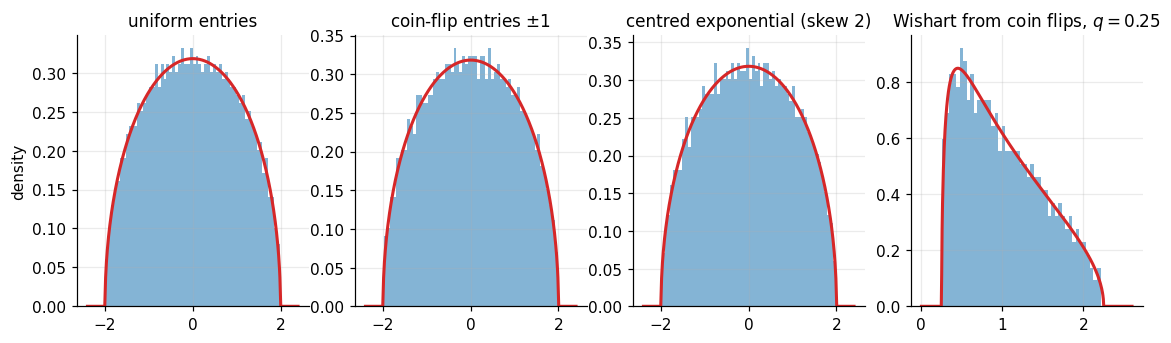

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
N = 1500
x = np.linspace(-2.4, 2.4, 500)
for ax, (d, ttl) in zip(axes[:3], [("uniform", "uniform entries"),
                                   ("rademacher", r"coin-flip entries $\pm 1$"),
                                   ("exponential", "centred exponential (skew 2)")]):
    lam = np.linalg.eigvalsh(wigner(N, rng, dist=d))
    esd(ax, lam, bins=60)
    ax.plot(x, semicircle_pdf(x), color=C3, lw=2)
    ax.set_title(ttl)

Nw, Tw = 500, 2000                                   # Wishart from coin flips
lam = np.linalg.eigvalsh(sample_cov(sample_entries("rademacher", (Nw, Tw), rng)))
esd(axes[3], lam, bins=45)
xw = np.linspace(1e-3, 2.6, 500)
axes[3].plot(xw, mp_pdf(xw, Nw / Tw), color=C3, lw=2)
axes[3].set_title("Wishart from coin flips, $q=0.25$")
axes[0].set_ylabel("density")

Astonishingly...**nothing moves!**. Whether we are looking at uniform distributed 
entries, coin flips or skewed exponentials for Wigner matrices their spectrum is 
indistinguishable from the Gaussian one. And the fourth panel makes the same point for MP, 
built from coin flips rather than Gaussians.

This is **universality**, namely, the limiting spectral density depends on the entry
distribution *only through its variance* (like in the CLT). The rest is all forgotten.

However, just like when one deals with the  CLT, universality comes with fine prints
(hey things were going too well, the catch had to come around). In particular:

- **Bulk**: finite *variance* is enough. The MP band and Wigner's semicircle survive anything
  with two moments.
- **Edge**: needs a finite **fourth moment**. The largest eigenvalue sticks to
  $\lambda_+$ (with TM and LDT fluctuations) iff $\mathbb{E}[x^4] < \infty$. If that is
  not the case then the edge belongs to the largest individual *entries*, not to the collective.

Finance runs on daily returns with tail exponents around 3–4 (the "cubic law"). As such, the
variance exists but the fourth moment is borderline-to-infinite. **Markets live exactly on
the fine print**. Lucky us...

## Part 4 — Fat tails I

To study fat tails we implement Student-t entries (we could have used also pareto-like distributions), 
standardised to unit variance, with the tail parameter $\nu$ as our dial-turning parameter. For Student-t
distributions the variance exists for $\nu > 2$, the fourth moment for $\nu > 4$. We can thus study what happens 
when we move through various boundaries. In particular, we sweep $\nu = 8, 5, 3, 2.5$ — namely, from "Gaussian with a slight paunch" to "cubic-law-ish and below". We keep $q = 1/3$ throughout.

Text(0, 0.5, 'density')

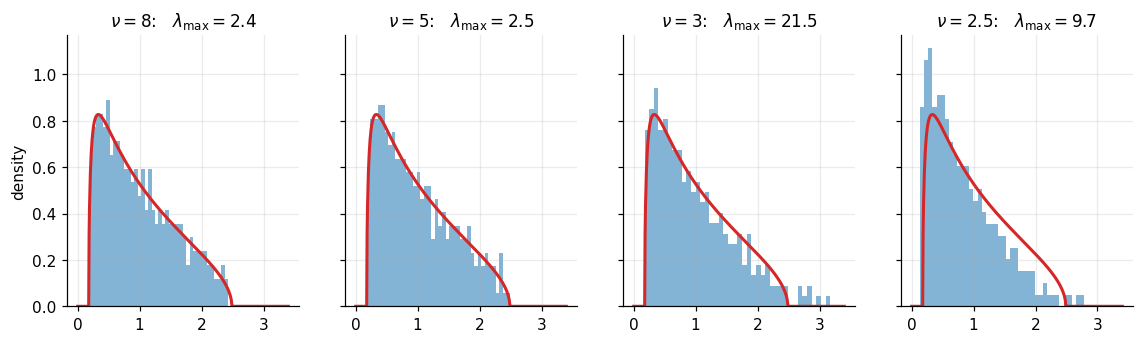

In [9]:
NUS = [8, 5, 3, 2.5]
N, T = 300, 900
q = N / T
lp = mp_edges(q)[1]

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2), sharey=True)
x = np.linspace(1e-3, 3.4, 500)
for ax, nu in zip(axes, NUS):
    lam = np.linalg.eigvalsh(sample_cov(returns_student(N, T, nu, rng, elliptical=False)))
    esd(ax, lam, bins=40, clip=(0, 3.2))
    ax.plot(x, mp_pdf(x, q), color=C3, lw=2)
    ax.set_title(rf"$\nu={nu}$:   $\lambda_{{\mathrm{{max}}}}={lam.max():.1f}$")
axes[0].set_ylabel("density")

The plot above shows the *bulk* of each spectrum against MP, with each panel reporting
$\lambda_{\max}$ (which can be easily compared to the TW and LDT expectations). 

In particular, we note that **the bulk does not care (much).** Down to $\nu = 3$ the bulk is essentially MP, and at $\nu = 2.5$ 
(where the variance is barely holding on) it is still not too bad, although with some crowding near the left edge 
since the in-sample scale itself wobbles when the variance is this reluctant to converge. To wit, and as 
expected, the bulk is not where fat tails show up.

On the other hand, it is clear that values for $\lambda_\mathrm{max}$ above LDT expactations are found below $ \nu = 4$. 
Now the fourth moment diverges and randomness alone can generate top eigenvalues well beyond what is accessible to a thin-tailed 
noise. But let us go deeper into the rabbit hole.

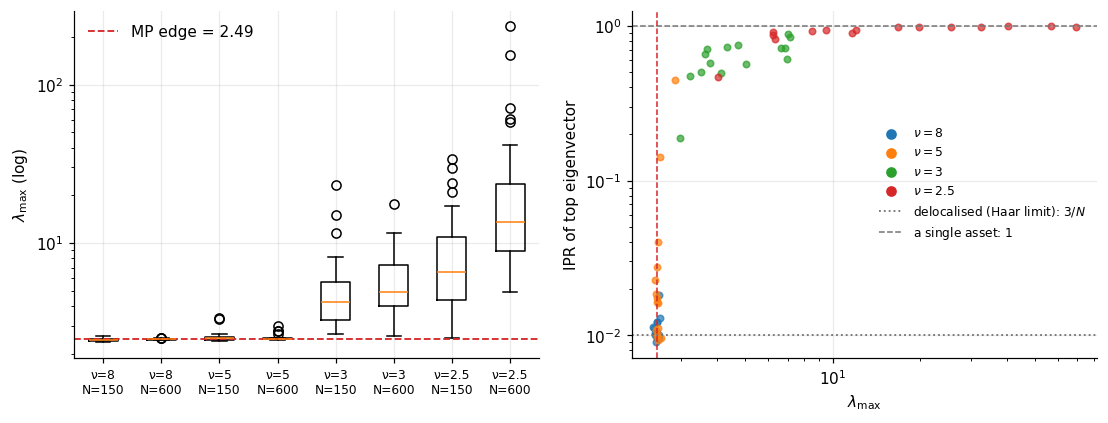

In [10]:
REPS = 30
sizes = (150, 600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.1))

# left: lambda_max across draws, two system sizes at fixed q ------------------
data, labels = [], []
for nu in NUS:
    for n in sizes:
        vals = [np.linalg.eigvalsh(
                    sample_cov(returns_student(n, 3 * n, nu, rng, elliptical=False))
                ).max() for _ in range(REPS)]
        data.append(vals)
        labels.append(f"ν={nu}\nN={n}")
ax1.boxplot(data)
ax1.set_xticks(range(1, len(labels) + 1))
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_yscale("log")
ax1.axhline(lp, color=C3, ls="--", lw=1.2, label=f"MP edge = {lp:.2f}")
ax1.set_ylabel(r"$\lambda_{\mathrm{max}}$ (log)")
ax1.legend()

# right: what is the top eigenvector made of? ---------------------------------
for nu, c in zip(NUS, (C0, C1, C2, C3)):
    for _ in range(15):
        lam, u = eigh_desc(sample_cov(returns_student(300, 900, nu, rng, elliptical=False)))
        ax2.scatter(lam[0], ipr(u[:, 0]).item(), color=c, s=18, alpha=0.7)
    ax2.scatter([], [], color=c, label=rf"$\nu={nu}$")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.axhline(3 / 300, color="0.45", ls=":", lw=1.2, label="delocalised (Haar limit): $3/N$")
ax2.axhline(1.0, color="0.45", ls="--", lw=1, label="a single asset: $1$")
ax2.axvline(lp, color=C3, ls="--", lw=1)
ax2.set_xlabel(r"$\lambda_{\rm max}$"); ax2.set_ylabel("IPR of top eigenvector")
ax2.legend(fontsize=8);

Above plot: in the left panel we show the Box-and-whisker summary of $\lambda_\mathrm{max}$ across 30 
independent draws per configuration; in the right panel we show the per-draw scatter of $\lambda_\mathrm{max}$ 
against the inverse participation ratio $\mathrm{IPR}=\sum_i v_i^4$ of its top eigenvector (namely, 
one over the effective number of assets that mode occupies).

Here we see in the left panel that **the eigenvalues' edge splits below $\nu = 4$**. At $\nu=8$, $\lambda_{\max}$ is
pinned to the MP edge at both system sizes. At $\nu=5$ the fourth moment exists, and the edge holds asymptotically. 
Nonetheless, we must beware its slow convergence and we see that the occasional outlier appears (preasymptotics: 
"eventually" effectively means "later than our dataset"). At $\nu=3$ and $2.5$ the edge just blows up: the median
$\lambda_{\max}$ roughly **doubles** when $N$ goes from 150 to 600 at fixed $q$. 

The right panel using IPR instead questions directly the eigenvector associated to the top eigenvalues.
The Gaussian-ish draws sit at the expected IPR $\approx 3/N \approx 0.01$ of the Haar limit. Namely, the top
eigenvector spreads over everything, as a factor should. The $\nu < 4$ detached eigenvalues instead go to IPR $\approx 1$.
To wit, **the "factor" is one asset on one stretch of time**. In other words, a single fat entry of $X$ dominates
and appears as a factor to trade upon. Lies I say. 

The punchline? Well, with fat tails, **the top of the spectrum — exactly where one goes looking for a signal — is                     where the lies concentrate.**  Note also that the extreme is pinned to the mechanism. In particular, the largest eigenvalue 
is pinned to the largest single event. 

#### Looking in the abyss of raw data

RMT is based on the study of the SCM and the EDS. However, it is always of interest to 
look for complementary statistics and approaches. In particular, one could ask whether appraoches exist that would have allowed us to expect what we discovered about the EDS under fat tails directly from the raw draws. They do,
and the master of these type of approaches is N. N. Taleb from whom we recover a couple of interesting 
metrics (see Taleb (2025), *Statistical Consequences of Fat Tails*).

In particular, we consider:

1. The **max-to-sum ratio** $R_n(p) = \max_i |x_i|^p \,/\, \sum_i |x_i|^p$, which tends
to 0 in the large $N$ limit iff $\mathbb{E}|X|^p < \infty$. To wit, if a single observation keeps owning
a finite share of the sum, the $p$-th moment is a fiction of your sample (which bounds the supports). In this
case how can you trust stuff like sample kurtosis and GARCH fits or TW-edge reasoning?

2. The **preasymptotic $\kappa$**: defined through the mean absolute deviation (MAD) of an $n$-sum, $M(n) \propto n^{1/(2-\kappa)}$. 
Gaussian-speed aggregation is $\kappa = 0$, whilst $\alpha$-stable distributions give $\kappa = 2 - \alpha$. 
Overall, every tenth of $\kappa$ is extra data you need to collect before convergences can even start. 

Preasymptotic κ(1, 30) — 0 = Gaussian-speed aggregation; 2−α for α-stable:
   t(ν=  8):        κ = 0.036
   t(ν=  5):        κ = 0.070
   t(ν=  3):        κ = 0.184
   t(ν=2.5):        κ = 0.256
   α-stable(1.5):   κ = 0.518    (theory: 2 − α = 0.5)


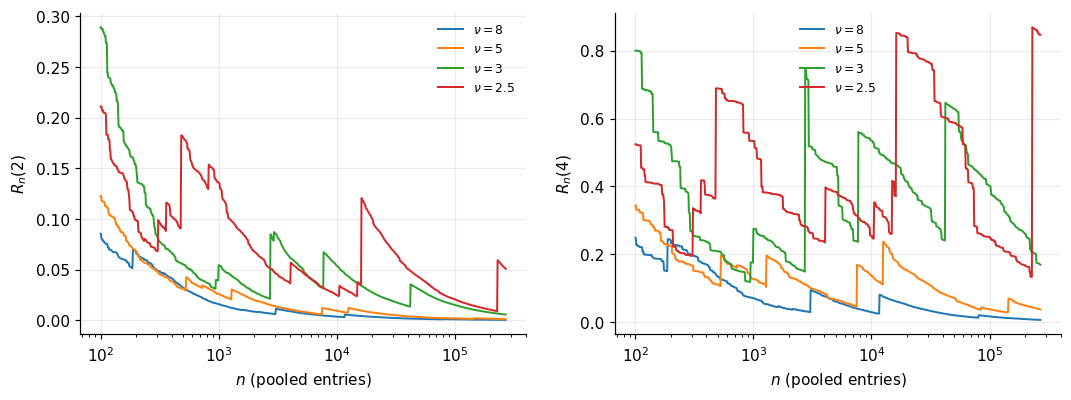

In [11]:
rng_tb = np.random.default_rng(7207)          # local generator: downstream draws untouched
NUS_TB = [8, 5, 3, 2.5]
POOL = 270_000                                # ~ the N*T of this Part's panels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8), sharex=True)
idx = np.unique(np.logspace(2, np.log10(POOL - 1), 900).astype(int))
for nu, c in zip(NUS_TB, (C0, C1, C2, C3)):
    a = rng_tb.permutation(rng_tb.standard_t(nu, POOL))
    for ax, p in ((ax1, 2), (ax2, 4)):
        ax.plot(idx, max_to_sum_ratio(a, p)[idx], color=c, lw=1.3, label=rf"$\nu={nu}$")
ax1.set_xscale("log"); ax2.set_xscale("log")
ax1.set_xlabel("$n$ (pooled entries)")
ax2.set_xlabel("$n$ (pooled entries)")
ax1.set_ylabel("$R_n(2)$")
ax2.set_ylabel("$R_n(4)$")
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)


print("Preasymptotic κ(1, 30) — 0 = Gaussian-speed aggregation; 2−α for α-stable:")
for nu in NUS_TB:
    k = kappa(lambda size, rg, nu=nu: rg.standard_t(nu, size), 30, rng=rng_tb)
    print(f"   t(ν={nu:>3}):        κ = {k:.3f}")
k_st = kappa(lambda size, rg: sample_stable(1.5, size, rg), 30, rng=rng_tb)
print(f"   α-stable(1.5):   κ = {k_st:.3f}    (theory: 2 − α = 0.5)")

Awesome... they work well!

**The $\kappa$ variable scouts directly the preasymptotics.** Indeed, this is (near) zero at $\nu=8$, 
climbing through $\approx 0.2$ at $\nu=3$ and even beyond at $\nu=2.5$, with the $\alpha$-stable landing directly
on $2-\alpha$ (good sanity check). The print-out table worked well.

The plots shows a complementary story. The left panel displays $R_n(2)$. This sinks for every $\nu$, 
as expected. Here, the second moment exists and the statistics must converge to zero. However, note 
again the preasymptotic: as $\nu$ decreases the number of entries needed to see the convergenes increases 
dramatically! Overall, looking at $R_n(2)$ sinking is essentially observing the ESD bulk's robustnes from the raw data.
Quite remarkable if you ask me.

Finally, the $R_n(4)$ (right panel) splits the family exactly on the fourth-moment line. The fastest
to "converge" is $\nu=8$, followed by a reluctant $\nu=5$ (the same reluctance as its edge excursions).
And then? Well, then, **for $\nu \leq 3$ $R_n(4)$ refuses to sink even after $10^5$ points.** We can
clearly see both $\nu=3$ and $\nu=2.5$  *jump back up past 0.5* in mid-sample, with a single
observation seizing most of the entire sum. Those jumps **are** the fake factors of the boxplots,
seen before any linear algebra.

The way I see using this operationally (but I might be wrong mind you!): we pool the $N\times T$ 
returns standardised by a *robust* scale (i.e., MAD$/0.6745$ and not the sample vol, or the 
denominator might be influenced too much by the tail), then we read e.g., $R_n(4)$ twice.
First, we use its **trend** across decades of $n$ to answer (try at least) "is there a fourth moment?". 
Then we use its **level** to answer the question: what share of any fourth-moment-dependent quantity rests
on a single observation. If that level is still north of $\approx 0.2$ at your working $n$, you are in deeeep trouble.

## Part 5 — Fat tails II

In Part 4 we considered fat tails distributions in the sense that every entry of $X$ was
independently heavy. However, in markets the heaviness is largely **shared**. In other words, on
a big day, most things are big. Or again, volatility is common across assets and clustered in
time. The minimal model of this is the *elliptical* Student-t:

$$r_t = \sqrt{\tfrac{\nu}{s_t}}\; z_t, \qquad s_t \sim \chi^2_\nu \ \text{(one draw per day)}\, ,$$

which has exactly the same $t(\nu)$ marginals as Part 4's iid version — i.e., same tails
asset by asset — but one common random scale per day. Note, of course, that we still have 
zero correlation between *directions*. 

We wish to compare the sample **correlation** spectra (per-asset standardisation included, for now std but MAD would be better) 
of three worlds with identical truth ($C = I$) and, for the two $t$ worlds, identical marginals. However,
before going there we will look at the raw data itself of the 2 fat-tail-dominated worlds. Just to 
really drill the difference in between the fat tails of Part 4 and those here considered.

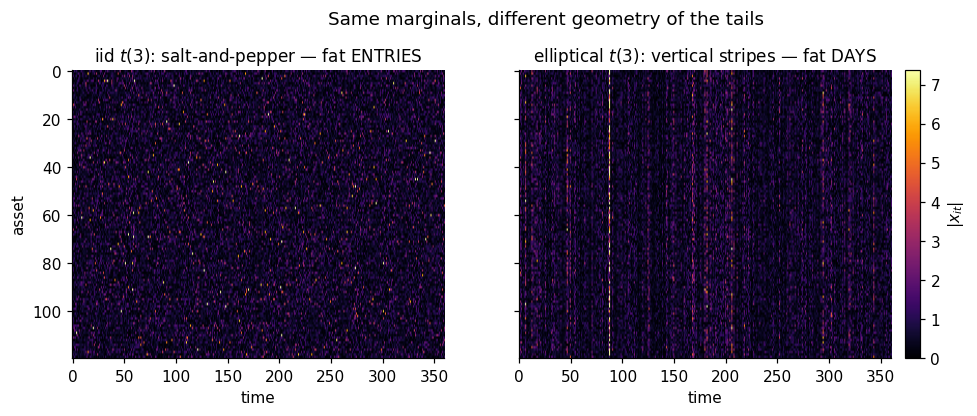

In [12]:
rng_hm = np.random.default_rng(5150)          # local generator, plots only
Nh, Th = 120, 360
Xi = returns_student(Nh, Th, 3.0, rng_hm, elliptical=False)
Xe = returns_student(Nh, Th, 3.0, rng_hm, elliptical=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), sharey=True)
vmax = np.quantile(np.abs(np.concatenate([Xi, Xe])), 0.999)
for ax, Xp, ttl in ((axes[0], Xi, "iid $t(3)$: salt-and-pepper — fat ENTRIES"),
                    (axes[1], Xe, "elliptical $t(3)$: vertical stripes — fat DAYS")):
    im = ax.imshow(np.abs(Xp), aspect="auto", cmap="inferno", vmin=0, vmax=vmax)
    ax.set_xlabel("time"); ax.grid(False)
    ax.set_title(ttl)
axes[0].set_ylabel("asset")
fig.colorbar(im, ax=list(axes), label=r"$|x_{it}|$", pad=0.015)
fig.suptitle("Same marginals, different geometry of the tails", y=1.04);

The above plots makes things quite clear. The iid world's extremes are **pixels** whilst the elliptical world's extremes are
**columns**. And the ESD edge simply shadows this geometric fact. A fat pixel builds a rank-one spike living on one asset (localised
eigenvector), while a fat column builds a rank-one spike $\sigma_t^2 z_t z_t^\top$ along a *random cross-sectional direction*.

Text(0, 0.5, 'density')

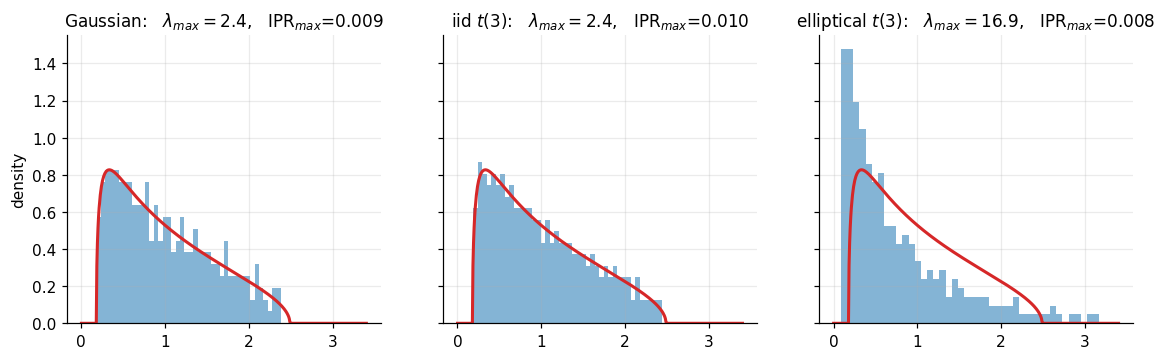

In [13]:
N, T = 300, 900
q = N / T
lp = mp_edges(q)[1]
cases = [
    ("Gaussian", returns_gaussian(N, T, rng)),
    (r"iid $t(3)$", returns_student(N, T, 3.0, rng, elliptical=False)),
    (r"elliptical $t(3)$", returns_student(N, T, 3.0, rng, elliptical=True)),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
x = np.linspace(1e-3, 3.4, 500)
for ax, (name, X) in zip(axes, cases):
    lam, u = eigh_desc(sample_corr(X))
    esd(ax, lam, bins=42, clip=(0, 3.2))
    ax.plot(x, mp_pdf(x, q), color=C3, lw=2)
    ax.set_title(rf"{name}:   $\lambda_{{max}}={lam[0]:.1f}$,   IPR$_{{max}}$={ipr(u[:, 0]).item():.3f}")
axes[0].set_ylabel("density")

So, we read off a few things here.

1. **The iid-$t$ panel seems in contrast with Part 4 (but it isn't).** Indeed, the standard per-asset standardisation 
kills this type of fat entries, the bulk is MP, and whatever escapes the edge is relatively *delocalised*.

2. **The elliptical panel is a different animal.** Now, the MP bulk is *replaced* with a fifth of the spectrum falling outside the MP band. Interestingly, the outlier's IPR across asset is **small**, i.e., the spurious eigenvalue is delocalised. It is correctly mimicking 
a market-mode costume. We can see how this would come to pass on the estimator itself. To wit, with $E = \frac{1}{T}\sum_t \sigma_t^2\, z_t z_t^\top$ and $\sigma_t^2$ heavy-tailed, a handful of monster days dominate the average, and the matrix ends up measuring **which days were wild, not which assets co-move**.

So, once again, *mai una gioia*. Why? Because our results forces a correction to the IPR test. Delocalisation alone does *not* certify a factor since a real market mode and a single panic day are identical in the cross-section. A time-axis IPR is instead needed to separate them. To wit,  **"Eigenvalue past the MP edge ⇒ factor" over-detects catastrophically. Not good at all!**

Also, as it is well known **real returns are not elliptical.** Real vol is only partly synchronised, and this kills a simple 
elliptical model (see e.g., Chicheportiche & Bouchaud 2012). Nonetheless, a dominant common volatility mode is among the best-documented facts in equities, so our approach was to work on a realistic starting zeroth-order model. But things are more complicated than what we have shown here.

FInally, to close our bit about fat tails and move on to cleaning covariance matrices let us look at the cliff at the edge of universality's basin: entries with **infinite variance** making up **Lévy Matrices**.

largest |eigenvalue|: 124.2   (semicircle would say: 2)


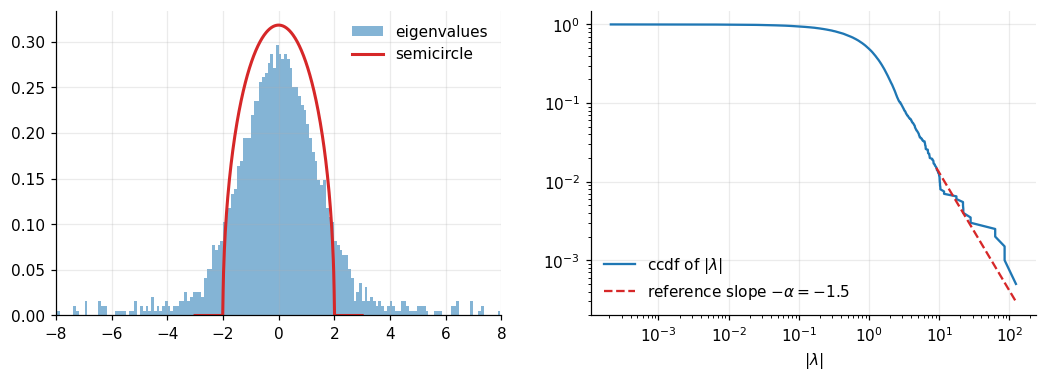

In [14]:
N_LEVY, ALPHA = 2000, 1.5
lam = np.linalg.eigvalsh(wigner(N_LEVY, rng, dist="stable", alpha=ALPHA))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.6))
esd(ax1, lam, bins=160, clip=(-8, 8))
x = np.linspace(-3, 3, 400)
ax1.plot(x, semicircle_pdf(x), color=C3, lw=2, label="semicircle")
ax1.set_xlim(-8, 8)
ax1.legend()

a = np.sort(np.abs(lam))
cc = 1.0 - np.arange(1, a.size + 1) / a.size
keep = cc > 0
ax2.loglog(a[keep], cc[keep], color=C0, lw=1.5, label=r"ccdf of $|\lambda|$")
x0 = np.quantile(a, 0.985)
xs = np.array([x0, a[-2]])
ax2.loglog(xs, 0.015 * (xs / x0) ** (-ALPHA), color=C3, ls="--",
           label=rf"reference slope $-\alpha=-{ALPHA}$")
ax2.set_xlabel(r"$|\lambda|$")
ax2.legend()
print(f"largest |eigenvalue|: {a[-1]:.1f}   (semicircle would say: 2)")

With $\alpha < 2$ the variance of the entries is infinite and we exit the semicircle's
basin of attraction altogether. Now, the limiting spectral density (see Cizeau–Bouchaud 1994) has
a cusp, unbounded support, and a power tail whose exponent tracks the entries' own
$\alpha$. To wit, the *EDS itself* is now fat-tailed, and eigenvectors at the far edges
localise. 

For our own peace of mind: equity returns are generally not $\alpha$-stable, as their tail exponents cluster around
3–4 (the cubic law). Thank la Dea Fortuna! These sit safely inside the "variance exists" bit. 

## Part 6 — Planting truth: spiked covariances and the BBP transition

We now wish to understand how to actually look for some "signal buried in noise" within RMT. To this end we use the simple model of
spiked covariances. Namely, we now define our population covariance as

$$C = I + \sum_{k} (\ell_k - 1)\, v_k v_k^\top\,,$$

where we are considering orthonormal directions $v_k$ with strengths $\ell_k > 1$. In particular, we 
consideer a **market mode** ($v_1$ with $\ell = 10$), two "sectors" ($\ell = 4$ and $2$), and one deliberately 
feeble factor ($\ell = 1.3$). We consider Gaussian returns (no fat tails), and $q = 0.25$. We are now gauging pure estimation error
in a simpler world leaving the problem of the interaction with fat tails for later. 

In this case, the work by Baik–Ben and Arous–Péché (see e.g., their seminal 2005 paper), as well as their successors, tells us that:
in the limit $N \to \infty$ a spike $\ell$ produces an eigenvalue **outside** the MP bulk in the thin-tailed world iff

$$\ell > 1 + \sqrt{q}\,,$$

in which case the outlier sits not at $\ell$ but at 

$$\lambda(\ell) = \ell + \frac{q\,\ell}{\ell-1}\, ,$$

Additionally, in this case, the sample eigenvector $u$ recovers the true direction $v$ only partially, i.e., we have

$$|\langle u, v\rangle|^2 \;\to\; \frac{1 - q/(\ell-1)^2}{1 + q/(\ell-1)} \; < \; 1 .$$

At $q = 0.25$ the threshold is readily computed to $\ell^* = 1.5$. Therefore, our feeble $\ell = 1.3$ factor is
*below* it. We do not expect to see it.

,ℓ (true),λ observed,λ theory,overlap² observed,overlap² theory
0,10.0,10.214,10.278,0.968,0.970
1,4.0,4.355,4.333,0.899,0.897
2,2.0,2.488,2.500,0.584,0.600
3,1.3,2.258,2.250,0.003,0.000


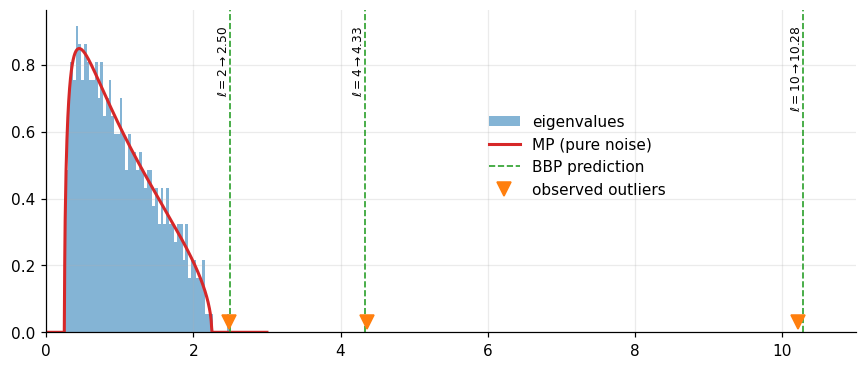

In [15]:
N, T = 500, 2000
q = N / T
ELLS = [10.0, 4.0, 2.0, 1.3]
Ctrue, Vtrue = spiked_cov(N, ELLS, rng)
lam, u = eigh_desc(sample_cov(returns_gaussian(N, T, rng, cov=Ctrue)))
lm, lp = mp_edges(q)

fig, ax = plt.subplots(figsize=(9.5, 3.8))
esd(ax, lam, bins=60, clip=(0, 3.0))
x = np.linspace(1e-3, 3.0, 500)
ax.plot(x, mp_pdf(x, q), color=C3, lw=2, label="MP (pure noise)")

spikes = [e for e in ELLS if e > bbp_threshold(q)]
for k, ell in enumerate(spikes):
    th = spike_lambda(ell, q)
    ax.axvline(th, color=C2, ls="--", lw=1.1,
               label="BBP prediction" if k == 0 else "_nolegend_")
    ax.annotate(rf"$\ell={ell:g}\rightarrow{th:.2f}$", xy=(th, 0.92),
                rotation=90, fontsize=8, ha="right", va="top")

out = lam[lam > lp * 1.02]
ax.plot(out, np.full(out.size, 0.03), "v", color=C1, ms=9, label="observed outliers")
ax.set_xlim(0, 11)
ax.legend(bbox_to_anchor=(0.53, 0.72))

rows = []
for i, ell in enumerate(ELLS):
    rows.append({
        "ℓ (true)": ell,
        "λ observed": lam[i],
        "λ theory": float(spike_lambda(ell, q)),
        "overlap² observed": float((u[:, i] @ Vtrue[:, i]) ** 2),
        "overlap² theory": float(spike_overlap2(ell, q)),
    })
pd.DataFrame(rows).round(3)

We note that the theory columns land on the observations to a couple of decimals, which is completely 
expected given the finite $N$ we are considering. Now, what do we get out of our little experiment?

- **$\ell = 10$ (market):** more than clearly visible! With a nice overlap between the directions of 
  $\approx 0.97$. Strong factors are easy. Who could have imagined so?
- **$\ell = 4, 2$:** still visible (hell yeah), but with the caveat that the $\ell = 2$ direction is 
  recovered with only $\approx 60\%$ overlap (hell nah). In other words, a portfolio built on that eigenvector 
  is 40% noise, *and nothing in the sample tells you so*...
- **$\ell = 1.3$:** nothing. We see nothing. Actually almost less than nothing. It is not that
  the information is not hard to extract. The point is that below the threshold the information is
  **not there**. Full stop. The spectrum of one sample is provably unable to distinguish this world from pure noise.

Now we can ask, is the threshold of detection sharp?

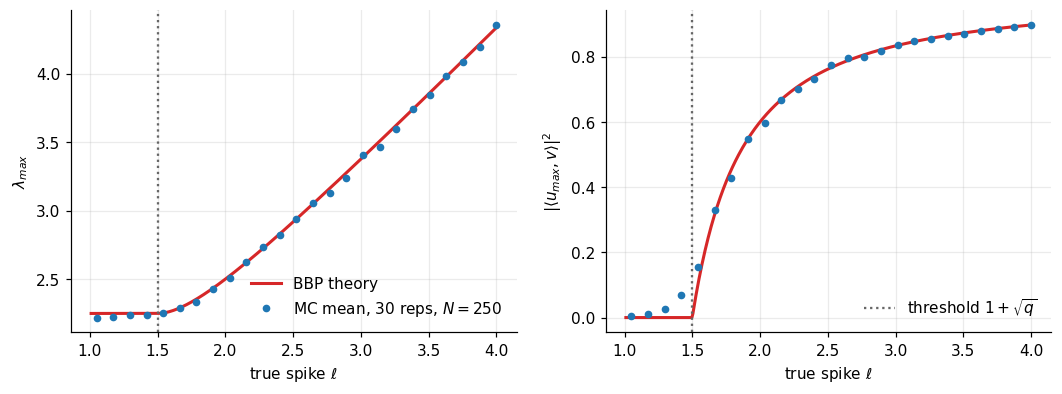

In [16]:
qq = 0.25
N2, T2, REPS = 250, 1000, 30
ells = np.linspace(1.05, 4.0, 25)
mean_lam, mean_ov = [], []
for ell in ells:
    Cs, Vs = spiked_cov(N2, [ell], rng)
    ls_, ov_ = [], []
    for _ in range(REPS):
        lam2, u2 = eigh_desc(sample_cov(returns_gaussian(N2, T2, rng, cov=Cs)))
        ls_.append(lam2[0])
        ov_.append((u2[:, 0] @ Vs[:, 0]) ** 2)
    mean_lam.append(np.mean(ls_))
    mean_ov.append(np.mean(ov_))

grid = np.linspace(1.01, 4.0, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax1.plot(grid, spike_lambda(grid, qq), color=C3, lw=2, label="BBP theory")
ax1.plot(ells, mean_lam, "o", color=C0, ms=4, label=f"MC mean, {REPS} reps, $N={N2}$")
ax1.axvline(bbp_threshold(qq), color="0.4", ls=":")
ax1.set_xlabel(r"true spike $\ell$"); ax1.set_ylabel(r"$\lambda_{max}$")
ax1.legend()

ax2.plot(grid, spike_overlap2(grid, qq), color=C3, lw=2)
ax2.plot(ells, mean_ov, "o", color=C0, ms=4)
ax2.axvline(bbp_threshold(qq), color="0.4", ls=":", label=r"threshold $1+\sqrt{q}$")
ax2.set_xlabel(r"true spike $\ell$"); ax2.set_ylabel(r"$|\langle u_{max}, v \rangle|^2$")
ax2.legend();

The plot above essentially presents the BBP phase transition, just softened at finite $N$. On the left panel, $\lambda_{\max}$ stays pinned at $\lambda_+$ until $\ell^\star = 1+\sqrt{q}$ and only then lifts off along $\ell\,(1+\tfrac{q}{\ell-1})$. On the right panel instead the softening is quite cler (i.e., missing it takes effort). To wit, the theory puts the squared overlap at *exactly* zero below the threshold, whilst the simulation already reaches $\approx 0.05$ at $\ell = 1.4$. As one could expect, the finite system feels the transition before it arrives.

From our exploration of spiked covariance, we carry some information out with us:

**1. Invisibility below the threshold is a fact.** Below $\ell^* = 1+\sqrt{q}$, no cleverness applied to *this sample's spectrum* reveals the factor. Full stop.

**2. What we can detect, we always over-estimate.** Really, it is just $\lambda(\ell) = \ell + q\ell/(\ell-1) > \ell$. The sample exaggerates every factor's strength. Therefore, any naive risk model that keeps raw top eigenvalues is *structurally* overconfident about factor risk. Not good.

**3. Detected ≠ estimated (part N).** The directions overlap climbs very slowly. Indeed at twice the threshold ($\ell = 3$) the overlap is still only $\approx 0.83$. To wit, there is a wide mesoscopic band of factors one can see but cannot trust. Another unhappiness joins us.

To do better, cleaning the RMT seems like the way to go. We turn to that next.

## Part 7 — The shoot-out: cleaning schemes vs the oracle

In this notebook we have investigated (i) why naive SCM use is madness; (ii) Wigner's semicircle and MP as universal thin-tailed attractors for ESD; (iii) TW and LDT to look at the fluctuations of the edge of ESD (where the signal should live); (iv) how fat tails noise completely changes the picture (whether by iid entries or elliptical), allowing for way larger deviations in the eigenvalues; (v) that detection of true factors is hard, overestimated and with unsure directions using spiked covariances. Now, we want to use some of the known tools to make our life better and trust a bit more (but not too much) our estimates. In short, we want to clean our data, i.e., our sample covariance matrices. 

To do so, we fix as the underlying *true* population covariance the spiked covariance used in Part 6  (namely, $\ell = 10, 4, 2, 1.3$ on $N = 250$ assets) with $q \in \{0.25, 0.5\}$. We then employ RMT cleaning tools based on the following idea: "keep the sample eigenvectors but replace the eigenvalues $\lambda_i \to \xi_i$".

In particular we will use: 

- **Sample** — $\xi_i = \lambda_i$, i.e., the naive estimation we berated in Part 0 (and in the whole notebook really).
- **Clipping** — the MP bulk is just noise and we do not care for it. Therefore everything in the ESD below $\lambda_+$ is averaged to a  constant, and everything above it is just kept *as is*. See Laloux, Cizeau, Bouchaud, and Potters (1999), PRL 83, 1467 — *Noise dressing of financial correlation matrices*.
- **Ledoit–Wolf** — this is a simple linear shrinkage $E \to \hat{E} =\rho\,\mu I + (1-\rho) E$, where $\mu = \operatorname{tr}(E)/N$ is the mean sample eigenvalue, and  $\rho$ is the one minimising the *expected* Frobenius distance $\||\hat{E} - C\||_F$. Interestingly, although $C$ in really always an unknwon, $\rho$ can still be *estimated* directly by the sample alone. See for details Ledoit & Wolf (2004), JMVA 88, 365-411 — *A well-conditioned estimator for large-dimensional covariance matrices*.
- **RIE (Rotationally Invariant Estimator)** — This is a rather nonlinear shrinkage given by $\xi_i = \lambda_i \,/\, |1 - q + q z_i g(z_i)|^2$, where $z_i = \lambda_i - i\eta$ sits just off the real axis, and $\mathfrak{g}(z) = \tfrac{1}{N}\sum_j (z - \lambda_j)^{-1}$ is the Stieltjes transform of the observed spectrum. Remarkably, it is computed from the observed spectrum alone, with each eigenvalue shrunked by exactly the amount its own eigenvector is expected to be off. See for a review Bun, Bouchaud, and Potters (2017), Phys. Rep. 666, 1 - 109 — *Cleaning large correlation matrices: tools from RMT*.
- **Oracle** — this is $\xi_i = u_i^\top C\, u_i$, namely the true variance along each sample eigenvector. It is the *ceiling* for all of our estimators and, of course, it is never available to practitioners. But here we can use it so it would be madneess not to include it!

To test the estimators we will use two scoreboards: (i) the **Frobenius error** on $C$ (i.e., matrix accuracy); and  (ii) the **believed vs realized vs optimal volatility** of the min-variance portfolio (namely, decision quality). Note very importantly that these are **not the same thing**.

However, to get a feeling  about each cleaning method, let us look first at their action of the eigenvalues of a draw of our matrix for $ q = 0.5$.

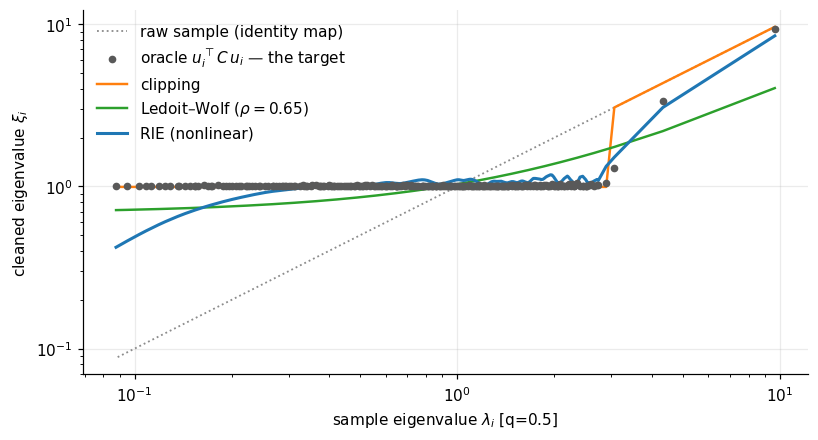

In [17]:
N, T = 250, 500
q = N / T
ELLS7 = [10.0, 4.0, 2.0, 1.3]
Ctrue, _ = spiked_cov(N, ELLS7, rng)
X = returns_gaussian(N, T, rng, cov=Ctrue)
lam, u = eigh_desc(sample_cov(X))

xi_o = xi_oracle(u, Ctrue)
xi_c = xi_clip(lam, q)
xi_r = xi_rie(lam, q)
_, rho, mu = lw_shrinkage(X)
xi_l = rho * mu + (1 - rho) * lam            # LW keeps E's eigenvectors: this is its map

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(lam, lam, ls=":", color="0.55", lw=1.2, label="raw sample (identity map)")
ax.scatter(lam, xi_o, s=16, color="0.35", zorder=5, label=r"oracle $u_i^\top C\, u_i$ — the target")
ax.plot(lam, xi_c, color=C1, lw=1.6, label="clipping")
ax.plot(lam, xi_l, color=C2, lw=1.6, label=rf"Ledoit–Wolf ($\rho={rho:.2f}$)")
ax.plot(lam, xi_r, color=C0, lw=2.0, label="RIE (nonlinear)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(rf"sample eigenvalue $\lambda_i$ [q={q}]")
ax.set_ylabel(r"cleaned eigenvalue $\xi_i$")
ax.legend();

"Una foto vale più  di mille parole", well so does a plot: 

- The **gray dots** (oracle) are what the eigenvalues *should* become, with small $\lambda$ pulled up, and the large bulk of ESD pulled down.
- The **identity map** is, of course, just wrong at both ends. I cannot stress this enough. For the love of la Dea Fortuna do not use it.
- **Clipping** nails the bulk-average (hell yeah) but keeps the top eigenvalues raw with the results that the dots sit below the orange line at the top (hell nah). Also, do note the expected sharpness at the MP edge.
- **Ledoit–Wolf** is the case in which one is always kind of wrong  but *never catastrophically* wrong, which is its whole appeal.
- **RIE** instead follows way better the dots across a total of three orders of magnitude, including the spike deflation. It is not perfect but it is doing a damn good job!

We can now safely set up our torunament and compile our scoringboards. To do so we run a total of 40 worlds and test the performances on each of these.

In [18]:
METHODS = ["sample", "clip", "lw", "rie", "oracle"]

def tournament(N, q, reps, gen, Ctrue):
    T = int(round(N / q))
    acc = {m: {"frob": [], "bel": [], "real": []} for m in METHODS}
    for _ in range(reps):
        X = gen(N, T, Ctrue)
        for m in METHODS:
            S = clean_cov(X, m, c_true=Ctrue)
            r = risk_report(S, Ctrue)
            acc[m]["frob"].append(frobenius(S, Ctrue))
            acc[m]["bel"].append(r["in_sample"])
            acc[m]["real"].append(r["realized"])
    out = pd.DataFrame({
        "Frobenius": {m: np.mean(a["frob"]) for m, a in acc.items()},
        "believed vol": {m: np.mean(a["bel"]) for m, a in acc.items()},
        "realized vol": {m: np.mean(a["real"]) for m, a in acc.items()},
        "realized p95": {m: np.quantile(a["real"], 0.95) for m, a in acc.items()},
    })
    out["believed/realized"] = out["believed vol"] / out["realized vol"]
    return out

gauss = lambda n, t, C: returns_gaussian(n, t, rng, cov=C)
REPS7 = 40
res = {f"q = {q_}": tournament(250, q_, REPS7, gauss, Ctrue) for q_ in (0.25, 0.5)}

opt_vol = np.sqrt(portfolio_variance(min_var_weights(Ctrue), Ctrue))
print(f"true optimal min-variance vol (unreachable ideal): {opt_vol:.4f}")

table = pd.concat(res, axis=1)
fmt = {c: "{:.4f}" for c in table.columns}
fmt.update({c: "{:+.1%}" for c in table.columns if c[1] == "excess risk vs oracle"})
(table.style.format(fmt))

true optimal min-variance vol (unreachable ideal): 0.2000


OK; we made a big table. Now we look at it step by step. To begin with, let us clarify what the columns represent and we are sure everyone is on board.

- **Frobenius** — $\||\hat{E} - C\||_F$, pure matrix accuracy. Note this is totally blind to what the matrix is used for.
- **believed vol** — $\sqrt{w^{\top}\hat{E}\,w}$, i.e., the risk the estimator *claims* its own portfolio carries.
- **realized vol** — $\sqrt{w^{\top}C\,w}$, namely the risk that portfolio *actually* carries.
- **realized p95** — the 95th percentile of the above across reps: to look at tail behaviour and not just the mean.
- **believed/realized** — the optimism ratio. Clearly $<1$ means you are understating your own risk.

Note that here *realized* is not a simulated path but the exact variance of the minimum variance portoflio $w =\hat{E}^{-1}\mathbf{1} / (\mathbf{1}^{\top}\hat{E}^{-1}\mathbf{1})$, where $\hat{E}$ is the final cleaned SCM, but istead under $C$. 

Now, a few comments:

**1. Looking at the Frobenius distance the theory matches.** Indeed, we see that we have, in descending order of Frobenius distance from $C$, sample ≫ Ledoit–Wolf > clipping > RIE (with RIE some 10–15% above the oracle's floor). Importantly, the gap between "any cleaning" and "no cleaning" dwarfs every gap among schemes. We state for the Nth time that using $E$ raw is essentially the original sin. 

**2. The realized column is the money column.** In numbers: the raw sample carries about $+8\%$ excess realized risk over the oracle at $q=0.25$ and about $+30\%$ at $q=0.5$, while the whole cleaned trio sits within $\sim 1\%$ of the ceiling. Interestingly, the *realized p95* column preserves the *realized-vol* ranking here. To wit, the averages are not hiding fragile tails as expected.

**3. Cleaning does buys back (a bit) of our trust.** The believed/realized column shows the whole picture. The raw sample believes *half* the risk it carries at $q=0.5$. Insane (part N+1). On the other hand cleaning lifts calibration to $\approx 0.7$ for $q = 0.5$ and $\approx 0.8$ for $q = 0.25$ (aside for the Ledoit–Wolf which is systematically below). We get better, but we do not reach one. Note that even the **oracle** believes ~25% less than it realizes at $q=0.5$. How come? Well because even if we "fixed" the eigenvalues part, our portfolio is still overfitting the sample **eigenvectors**.

**4. Ledoit–Wolf is funky.** To wit, it always delivers the minimum realized *and* the minimum believed volatility. However, it believes far *less* risk than it carries (ratio $\approx 0.60$ at $q=0.5$, the most overconfident of all the cleaned schemes). In other words, possibly the best decisions whilst giving the worst self-reports. Note also an important caveat. The choice of a spiked covariance means carrying over a homogeneous idiosyncratic variance, so that the Ledoit–Wolf procedure is secretly better specified than in general.

**5. RIE emerges as winner in the thin-tailed world in the end!** It is doing great all-around.

One stress test left: does any of this survive the fat tails of Parts 4 and 5?

In [19]:
def elliptical(n, t, C):
    return returns_student(n, t, 3.0, rng, cov=C, elliptical=True)

def iid_t3(n, t, C):
    return returns_student(n, t, 3.0, rng, cov=C, elliptical=False)

def with_daystd(gen):                            # std day-scale (on MAD vs std: note below)
    def g(n, t, C):
        X = gen(n, t, C)
        return X / X.std(axis=0, keepdims=True)
    return g

runs, keys = [], []
for q_ in (0.25, 0.5):
    runs.append(res[f"q = {q_}"])
    keys.append((f"q = {q_}", "Gaussian ref"))
    for fam, gen in [("ellipt t(3)", elliptical), ("entry t(3)", iid_t3)]:
        for var, g in [("raw", gen), ("day-std", with_daystd(gen))]:
            runs.append(tournament(250, q_, REPS7, g, Ctrue))
            keys.append((f"q = {q_}", f"{fam} {var}"))

realized = pd.concat([r["realized vol"] for r in runs], axis=1, keys=keys)
believed = pd.concat([r["believed vol"] for r in runs], axis=1, keys=keys)
honesty  = pd.concat([r["believed/realized"] for r in runs], axis=1, keys=keys)
print("Realized vol (lower = better):")
display(realized.round(4))
print("Believed vol — the risk each estimator claims to carry:")
display(believed.round(4))
print("Believed / realized — the honesty ratio (1.00 = calibrated, below 1 = overconfident):")
honesty.round(2)

Realized vol (lower = better):


q = 0.25                                                     \
       Gaussian ref ellipt t(3) raw ellipt t(3) day-std entry t(3) raw   
sample       0.2307          0.2526              0.2309         0.2231   
clip         0.2151          0.2262              0.2151         0.2111   
lw           0.2072          0.2017              0.2073         0.2013   
rie          0.2139          0.2266              0.2139         0.2094   
oracle       0.2135          0.2085              0.2134         0.2160   

                               q = 0.5                                      \
       entry t(3) day-std Gaussian ref ellipt t(3) raw ellipt t(3) day-std   
sample             0.2224       0.2829          0.3086              0.2816   
clip               0.2107       0.2202          0.2246              0.2201   
lw                 0.2024       0.2063          0.2010              0.2061   
rie                0.2093       0.2182          0.2335              0.2179   
oracle             0.2158       0.2169          0.2058              0.2168   

                                          
       entry t(3) raw entry t(3) day-std  
sample         0.2634             0.2610  
clip           0.2147             0.2140  
lw             0.2009             0.2017  
rie            0.2118             0.2116  
oracle         0.2145             0.2173

Believed vol — the risk each estimator claims to carry:


q = 0.25                                                     \
       Gaussian ref ellipt t(3) raw ellipt t(3) day-std entry t(3) raw   
sample       0.1730          0.1323              0.1730         0.1405   
clip         0.1789          0.1352              0.1788         0.1453   
lw           0.1465          0.0893              0.1466         0.0983   
rie          0.1753          0.1371              0.1753         0.1411   
oracle       0.1752          0.1144              0.1758         0.1558   

                               q = 0.5                                      \
       entry t(3) day-std Gaussian ref ellipt t(3) raw ellipt t(3) day-std   
sample             0.1459       0.1405          0.0961              0.1417   
clip               0.1510       0.1641          0.1115              0.1637   
lw                 0.1117       0.1248          0.0802              0.1246   
rie                0.1466       0.1581          0.1150              0.1579   
oracle             0.1662       0.1589          0.0999              0.1595   

                                          
       entry t(3) raw entry t(3) day-std  
sample         0.1147             0.1190  
clip           0.1332             0.1389  
lw             0.0870             0.0957  
rie            0.1272             0.1321  
oracle         0.1329             0.1471

Believed / realized — the honesty ratio (1.00 = calibrated, below 1 = overconfident):


q = 0.25                                                     \
       Gaussian ref ellipt t(3) raw ellipt t(3) day-std entry t(3) raw   
sample         0.75            0.52                0.75           0.63   
clip           0.83            0.60                0.83           0.69   
lw             0.71            0.44                0.71           0.49   
rie            0.82            0.61                0.82           0.67   
oracle         0.82            0.55                0.82           0.72   

                               q = 0.5                                      \
       entry t(3) day-std Gaussian ref ellipt t(3) raw ellipt t(3) day-std   
sample               0.66         0.50            0.31                0.50   
clip                 0.72         0.75            0.50                0.74   
lw                   0.55         0.60            0.40                0.60   
rie                  0.70         0.72            0.49                0.72   
oracle               0.77         0.73            0.49                0.74   

                                          
       entry t(3) raw entry t(3) day-std  
sample           0.44               0.46  
clip             0.62               0.65  
lw               0.43               0.47  
rie              0.60               0.62  
oracle           0.62               0.68

We have 3 tables about volatility — realized, believed, and their ratio — for the same two wolrd (elliptical fat tails and iid fat tails). In each of them we report the respcitve volatility (or ratio) obtained by each cleaning tool for a Gaussian reference, and the two families of fat tails with raw and standardized data.

As before, a few comments are now in order: 

**1. Under ellipticity the day-by-day standardisation works like a charm.**  Indeed, if we look at the blieved/realized table we find that with raw entries the shared fat tail randomness makes every estimator (oracle included) believe roughly half the risk it carries. Essentially as bad as the pure SCM in the thin-tailed world! Instead, if we day-standardise, then each column returns to its Gaussian
reference *to the second decimal*, at $q=0.25$ and $q=0.5$ alike. That is quite something.

**2. With fat-tailed entries luck runs out.** Indeed, fat entries cost roughly 0.10–0.15 of honesty at either $q$ (just compare the iid-raw to the Gaussian reference column by column) whilst day-standardisation does almost nothing. In this case, there is no
common scale to remove, and the believed number is read off a spectrum whose top edge carries fake localised spikes while its typical days run quiet. It might sound counterintuitive but under fat tails the number of quite days increases. It is just the weight of the wild ones that matters more. Dealing with this has to do with EVT and we will get to it but not now...

**3. Varying $q$ buys honesty (as expected).** Every column is more truthful at $q=0.25$ than at $q=0.5$ (the cleaned Gaussian floor: 0.82 vs 0.73).

**4. Ledoit–Wolf keeps being funky.** To wit, it delivers the lowest realized volatility in every world, coupled with the least honest row in every world (0.43–0.60 raw). 

Before passing on to the field checklist, a final general note on scales. The day-filter here uses the cross-sectional **std**, for the pragmatic reason that its units are the $L^2$ units every downstream ruler (MP edge, believed vol) assumes. In general I think one should prefer a **mean-absolute-deviation (MAD)** scale — linear rather than quadratic influence under an extreme — matched back to $L^2$ units through a consistency, or through a trace renormalisation. But again EVT toolkit here.

## Part 8 — The field checklist

In this notebook we looked at a bunch of simulations and I think we learned some lesson along the way. In the S&P / futures notebook (`narrative_rmt_market_data.ipynb`) we try to transform each lesson in a protocol to use.

| simulation lesson (Part) | field protocol |
|---|---|
| MP is the null model of no-correlation (2) | plot the empirical ESD against MP at the actual $q$; fit the effective $\sigma^2$ à la Laloux. What we expect? We expect a bulk *narrower* than naive MP, since real spikes absorb variance |
| the edge typically fluctuates at $N^{-2/3}$ (1) | never promote a borderline eigenvalue to "factor" on position alone, even in  a thin-tailed world TW give a typical wobbling of the edge|
| beyond the edge, noise pays $e^{-N\Psi_+}$ (2) | *if* in a thin-tailed world convert a decent outlier's distance beyond $\lambda_+$ into a p-value via the LD rate. |
| iid fat entries make localised fake outliers (4) | compute the IPR over assets for every outlier's eigenvector. If localised ⇒ suspect one stock, one event. Although keep in mind this is not definitive. |
| moment existence is checkable from raw data (4) | run max-to-sum $R_2, R_4$ and $\kappa$ on raw returns first. If $R_4$ refuses to sink, retire thin-world reasoning. It does not apply. Beware especially variances as the sample will lie *a lot*. |
| common volatility deforms the bulk (5) | compare the spectrum before/after volatility filtering (e.g., via cross-sectional day-standardisation). Deviations that vanish were never factors |
| detected ≠ estimated (6) | track the eigenvectors overlap between disjoint windows. to wit, a "factor" whose direction does not persist out-of-sample is not a "factor" most of the time |
| cleaning ranked: sample < clip < LW ≲ RIE (7) | rolling out-of-sample min-variance race, scored on realized vol, believed-vs-realized |


**References.** 

- Marchenko & Pastur (1967), Mathematics of the USSR-Sbornik 1, 457 - 483 — *Distribution of eigenvalues for some sets of random  matrices*
- Laloux, Cizeau, Bouchaud, and Potters (1999), PRL 83, 1467 — *Noise dressing of financial correlation matrices*
- Plerou et al. (1999), PRL 83, 1471 — *Universal and nonuniversal properties of cross correlations in financial time series*
- Baik & Péché (2005), Ann. Probab. 33, 1643-1697 — *Phase transition of the largest eigenvalue for nonnull complex  sample covariance matrices*
- Dean & Majumdar (2006), PRL 97, 160201 — *Large Deviations of Extreme Eigenvalues of Random Matrices*
- Majumdar & Vergassola (2009), PRL 102, 060601 — *Large Deviations of the Maximum Eigenvalue for Wishart and Gaussian Random Matrices*
- Majumdar & Schehr (2014), J. Stat. Mech. P01012  — *Top eigenvalue of a random matrix: large deviations and third order phase transition*
- Ledoit & Wolf (2004), JMVA 88, 365-411 — *A well-conditioned estimator for large-dimensional covariance matrices*
- Ledoit & Péché (2011), Probab. Theory Relat. Fields 151, 233–264 — *Eigenvectors of some large sample covariance matrix ensembles*
- Bun, Bouchaud, and Potters (2017), Phys. Rep. 666, 1 - 109 — *Cleaning large correlation matrices: tools from RMT* (namely, the review this lab shadows)
- Cizeau & Bouchaud (1994), PRE 50, 1810 — *Theory of Lévy matrices*
- Chicheportiche & Bouchaud (2012), IJTAF 15, 1250019 — *The joint distribution of stock returns is not elliptical* 
- Potters & Bouchaud (2020) — *A First Course in Random Matrix Theory*
- Taleb (2025) - *Statistical Consequences of Fat Tails*